In [1]:
%matplotlib inline

In [2]:
import os
from pathlib import Path

import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.rc('figure', figsize=(6, 4.5))
mpl.rcParams['font.size'] = 10
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['figure.facecolor'] = 'w'
mpl.rcParams['hatch.linewidth'] = 0.5
mpl.rcParams['hatch.color'] = '0.25'

import xarray as xr
import xgcm

from scipy.special import erf
from numpy import pi as π

In [3]:
# trig functions that take degrees

def sind(x):
    return np.sin(np.deg2rad(x))

def cosd(x):
    return np.cos(np.deg2rad(x))

## Constants

In [4]:
ρ0 = 1035 # Boussinesq reference density
g = 9.8
Ω = 7.29e-5
a = 6370e3

# Make input directory

In [5]:
Path('./INPUT').mkdir(exist_ok=True)

# Create grid

In [15]:
grid = 'isotropic'

xw = 0
xe = 30
ys = 10
dx = 0.5

xq = np.arange(xw, xe+dx, dx)
xh = np.arange(xw+dx/2, xe, dx)

NX = len(xh)

if grid == 'latlon':
    yn = 45

    dy = 0.5

    yq = np.arange(ys, yn+dy, dy)
    yh = np.arange(ys+dy/2, yn, dy)
    NY = len(yh)
elif grid == 'isotropic': # aka Mercator
    NY = 81
    
    jh = np.arange(NY) + .5
    jq = np.arange(NY+1)

    yq = np.rad2deg(2*np.arctan(np.exp(jq*np.deg2rad(dx))*np.tan(π/4 + np.deg2rad(ys)/2)) - π/2)
    yh = np.rad2deg(2*np.arctan(np.exp(jh*np.deg2rad(dx))*np.tan(π/4 + np.deg2rad(ys)/2)) - π/2)
else:
    RuntimeError('unknown grid type')
    
dyq = a*np.deg2rad(np.diff(yh))
dyh = a*np.deg2rad(np.diff(yq))
dxq = a*np.deg2rad(dx)*cosd(yq)
dxh = a*np.deg2rad(dx)*cosd(yh)

Aq = dxq[1:-1]*dyq

# Layer configuration

In [8]:
# number of layers
NK = 2

# maximum depth

# interface depths
eta = np.array([
       0,
    -443, # this comes from the Parsons-Veronis calculation in Parsons-Veronis.ipynb
  -12000, # the last entry can be anything as long as it's deeper than the basin
], dtype=float) 

interface_IC = xr.Dataset(
    {'eta': (['nki'], eta, {'long_name': 'Initial depth of interfaces', 'units': 'meters'})},
)

interface_IC.to_netcdf('INPUT/interface_IC.nc')

In [9]:
interface_IC

<xarray.Dataset>
Dimensions:  (nki: 3)
Dimensions without coordinates: nki
Data variables:
    eta      (nki) float64 0.0 -443.0 -1.2e+04

# Topography - Erf-like shelves on eastern and western boundaries

## Case I: constant width in degrees

In [39]:
geolon, geolat = np.meshgrid(xh, yh)

λe = 30 # longitude of eastern boundary

Hshelf = 100 # shelf depth
Hmax = 4000

Lshelf = 1.5 # shelf width in degrees
Lslope = 1.5 # slope width in degrees

def H0(λ):
    return Hshelf + 0.5*(Hmax - Hshelf)*(1 + erf(np.sqrt(π)*((λ - Lshelf)/Lslope - 0.5)))

H = H0(geolon) + H0(λe - geolon) - Hmax

In [40]:
topog = xr.Dataset(coords={'yh': (['yh'], yh), 'xh': (['xh'], xh)})

topog['depth'] = (['yh', 'xh'], H, {'long_name': 'Ocean Depth', 'units': 'm'})

# topog.to_netcdf('INPUT/topog_degrees.nc')

topog

<xarray.Dataset>
Dimensions:  (xh: 60, yh: 81)
Coordinates:
  * yh       (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * xh       (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
Data variables:
    depth    (yh, xh) float64 101.6 123.8 284.7 886.7 ... 284.7 123.8 101.6

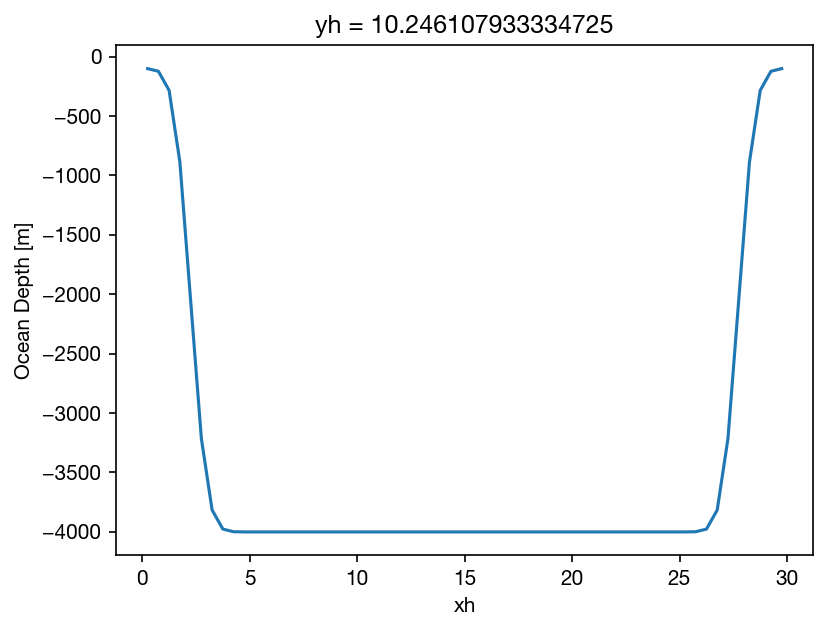

In [44]:
(-topog.depth).isel(yh=0).plot()

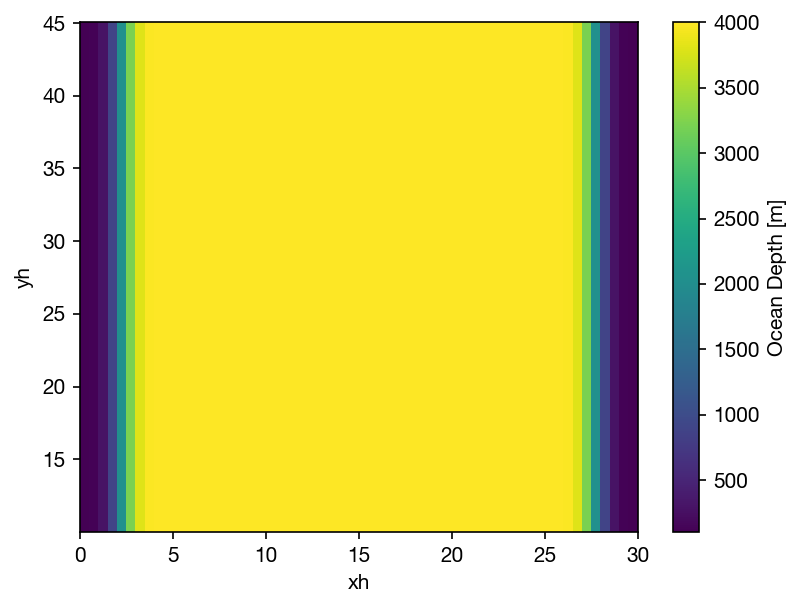

In [45]:
topog.depth.plot()

## Case II: constant width in kilometers - this is what we use

In [10]:
geolon, geolat = np.meshgrid(xh, yh)

x = a*np.deg2rad(geolon)*cosd(geolat)
λe = 30 # longitude of eastern boundary
Lx = a*np.deg2rad(λe)*cosd(geolat) # width of basin

Hshelf = 100 # shelf depth
Hmax = 4000

Lshelf = 150 # shelf width in kilometers
Lslope = 150 # slope width in kilometers

def H0(x):
    return 0.5*(Hmax - Hshelf)*(1 - erf(np.sqrt(π)*((x/1e3 - Lshelf)/Lslope - 0.5)))

H = Hmax - H0(x) - H0(Lx-x)

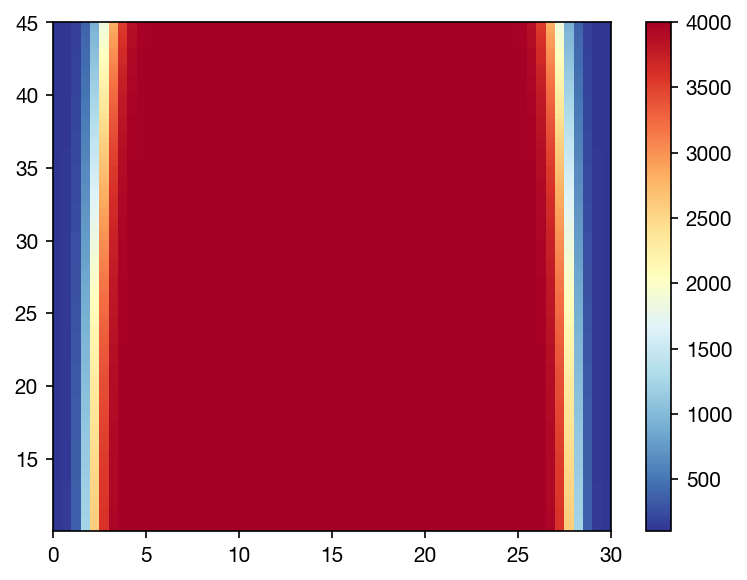

In [11]:
plt.pcolormesh(geolon, geolat, H, shading='auto')
plt.colorbar()

In [12]:
topog = xr.Dataset(coords={'yh': (['yh'], yh), 'xh': (['xh'], xh)})

topog['depth'] = (['yh', 'xh'], H, {'long_name': 'Ocean Depth', 'units': 'm'})

topog.to_netcdf('INPUT/topog_degrees.nc')

topog

<xarray.Dataset>
Dimensions:  (yh: 81, xh: 60)
Coordinates:
  * yh       (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * xh       (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
Data variables:
    depth    (yh, xh) float64 101.9 133.0 373.6 1.221e+03 ... 167.3 110.9 101.2

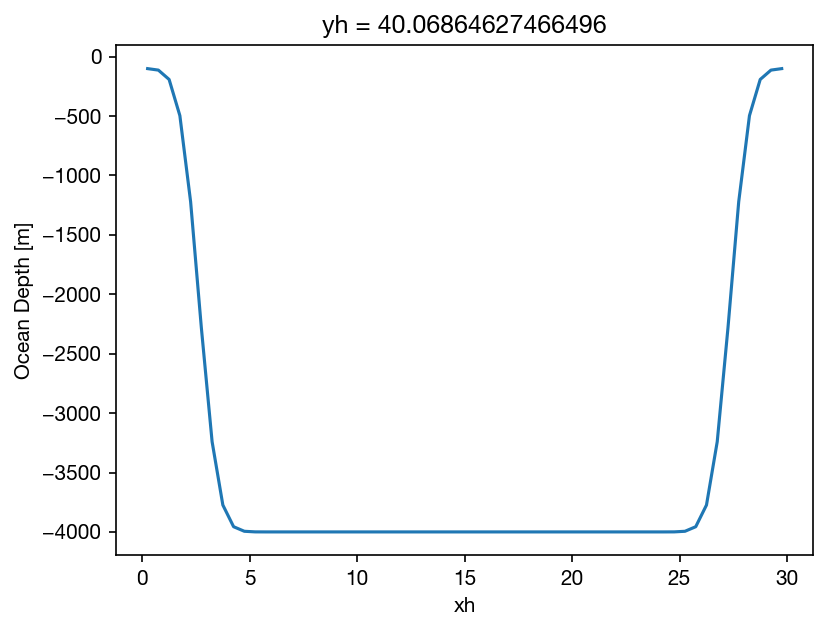

In [25]:
(-topog.depth).sel(yh=40, method='nearest').plot()

# Wind forcing

## Simple wind

In [70]:
τ0 = 0.15

θs = 15
θ0 = 35
θn = θ0 + (θ0 - θs)/2

In [71]:
taux = np.zeros((NY, NX+1))
tauy = np.zeros((NY+1, NX))
idx = yh >= θs
idx0 = np.nonzero(idx)[0][0]
taux[idx,:] = (τ0*np.cos(π*(yh[idx] - θ0)/((θ0-θs))))[:,np.newaxis]
taux[~idx,:] = -τ0
# taux[~idx,:] = taux[idx0,:]

a = 6370e3
ρ0 = 1035
Ω = 7.29e-5
dyh = a*np.deg2rad(np.diff(yh))
wsc = -np.diff(taux[:,0])/dyh
β = 2*Ω*cosd(yq[1:-1])/a
Lx = a*NX*np.deg2rad(dx)*cosd(yq[1:-1])

# Sverdrup transport
Tsv = Lx*wsc/(ρ0*β)

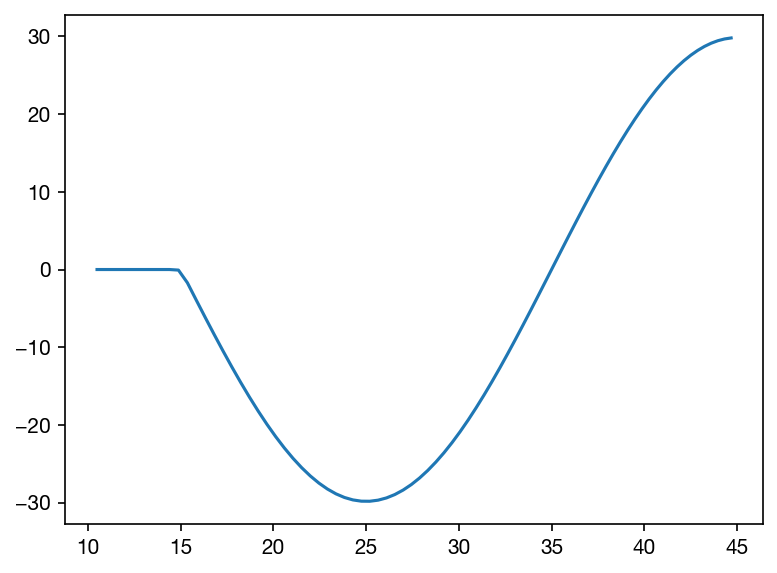

In [72]:
plt.plot(yq[1:-1], Tsv/1e6)

In [73]:
# MOM6 expects xq and yq to have be missing the last point
forcing = xr.Dataset(coords={
    'yh': (['yh'], yh), 
    'xh': (['xh'], xh),
    'yq': (['yq'], yq[:-1]), 
    'xq': (['xq'], xq[:-1]),
})

forcing['STRESS_X'] = (['yh', 'xq'], taux[:,:-1], {'long_name': 'Zonal Momentum Flux', 'units': 'Pa'})
forcing['STRESS_Y'] = (['yq', 'xh'], tauy[:-1,:], {'long_name': 'Meridional Momentum Flux', 'units': 'Pa'})

forcing.to_netcdf('INPUT/forcing.nc')

forcing

<xarray.Dataset>
Dimensions:   (xh: 60, xq: 60, yh: 81, yq: 81)
Coordinates:
  * yh        (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * xh        (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq        (yq) float64 10.0 10.49 10.98 11.47 ... 43.61 43.97 44.33 44.68
  * xq        (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 27.5 28.0 28.5 29.0 29.5
Data variables:
    STRESS_X  (yh, xq) float64 -0.15 -0.15 -0.15 -0.15 ... 0.0033 0.0033 0.0033
    STRESS_Y  (yq, xh) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

Read back in after running the model to make sure it took

In [21]:
ds = xr.open_dataset('forcing__0001_003.nc')
forcing_diag = ds
ds.close()

<xarray.Dataset>
Dimensions:     (Time: 2, nv: 2, xq: 61, yh: 100)
Coordinates:
  * xq          (xq) float64 0.0 0.5 1.0 1.5 2.0 ... 28.0 28.5 29.0 29.5 30.0
  * yh          (yh) float64 10.25 10.75 11.25 11.75 ... 58.25 58.75 59.25 59.75
  * Time        (Time) object 0001-01-03 12:00:00 0001-01-08 12:00:00
  * nv          (nv) float64 1.0 2.0
Data variables:
    taux        (Time, yh, xq) float32 ...
    average_T1  (Time) object ...
    average_T2  (Time) object ...
    average_DT  (Time) timedelta64[ns] ...
    Time_bnds   (Time, nv) timedelta64[ns] ...
Attributes:
    NumFilesInSet:  1
    title:          MOM Experiment
    grid_type:      regular
    grid_tile:      N/A

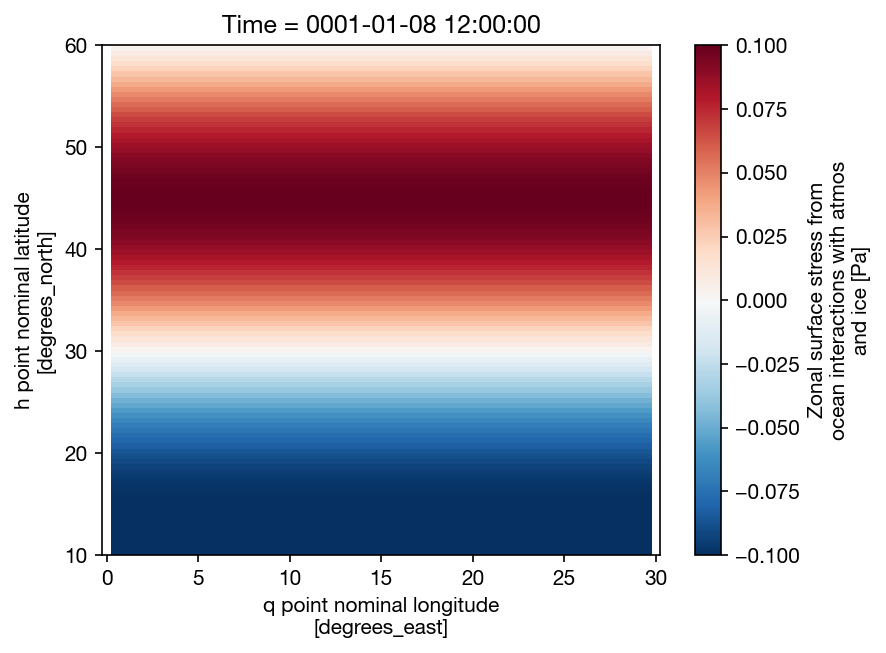

In [23]:
forcing_diag.taux.isel(Time=-1).plot()

## Simple curl

The wind forcing is the same as in the Parsons-Veronis notebook.

In [13]:
T0 = 20e6
ρ0 = 1035 # Boussinesq reference density
Ω = 7.29e-5
a = 6370e3

lonE = 30 # eastern boundary
λe = np.deg2rad(lonE)

V0 = T0/(a*λe*cosd(25))

def tau(θ, derivative=False):
    if derivative:
        return -(V0*Ω/(1386*np.cos(θ)**2))*np.piecewise(θ, 
                    [θ > np.deg2rad(15), θ <= np.deg2rad(15)],
                    [lambda θ: 315*np.sin(12*θ + π/4) + 994*np.sin(10*θ + π/4) + 1067*np.sin(8*θ + π/4) + 396*np.sin(6*θ + π/4) + 36*np.sin(θ), 
                     lambda θ: (190 + 81*np.sqrt(3))*np.sin(θ)])
    else:
        return (V0*Ω/(1386*np.cos(θ)))*np.piecewise(θ, 
                    [θ > np.deg2rad(15), θ <= np.deg2rad(15)],
                    [lambda θ: 63*np.cos(11*θ + π/4) + 154*np.cos(9*θ + π/4) + 99*np.cos(7*θ + π/4) - 36, 
                     lambda θ: -190 - 81*np.sqrt(3) ])


taux = ρ0*np.repeat(tau(np.deg2rad(yh))[:,np.newaxis], NX+1, axis=1)
tauy = np.zeros((NY+1, NX))



In [16]:
f = 2*Ω*sind(yh)
fq = 2*Ω*sind(yq)
β = 2*Ω*cosd(yh)/a
βq = 2*Ω*cosd(yq)/a
Lxh = a*np.deg2rad(xe-xw)*cosd(yh)
Lxq = a*np.deg2rad(xe-xw)*cosd(yq)


# net Ekman transport
Vek = -Lxh*tau(np.deg2rad(yh))/f

# Sverdrup transport
wsc = -np.diff(dxh*tau(np.deg2rad(yh)))/Aq
Vsv = (Lxq/βq)[1:-1]*wsc

# net geostrophic transport
wEk = -np.diff(dxh*tau(np.deg2rad(yh))/f)/Aq
Vg = (Lxq*fq/βq)[1:-1]*wEk

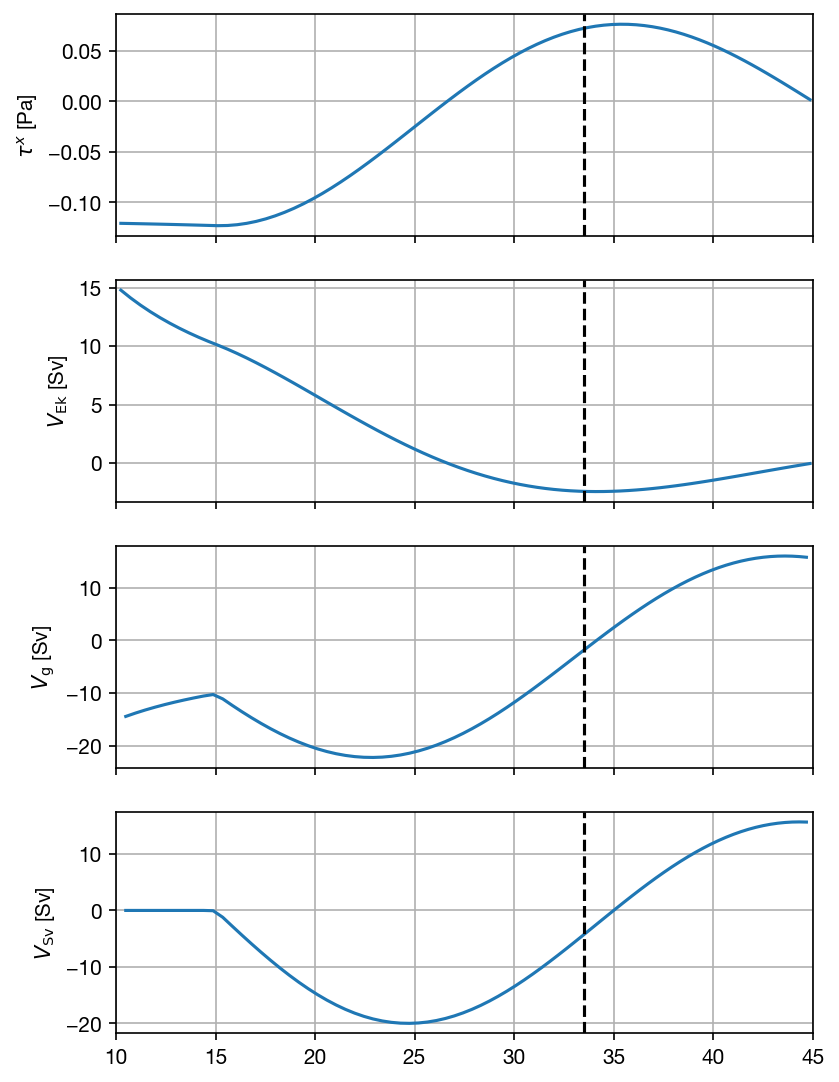

In [17]:
fig, axs = plt.subplots(nrows=4, sharex=True, figsize=(6, 9))

ax = axs[0]
ax.plot(yh, taux[:,0])
ax.set_ylabel(r'$\tau^x$ [Pa]')

ax = axs[1]
ax.plot(yh, Vek/1e6)
ax.set_ylabel(r'$V_\mathrm{Ek}$ [Sv]')

ax = axs[2]
ax.plot(yq[1:-1], Vg/1e6, '-')
ax.set_ylabel(r'$V_\mathrm{g}$ [Sv]')

ax = axs[3]
ax.plot(yq[1:-1], Vsv/1e6)
ax.set_ylabel(r'$V_\mathrm{Sv}$ [Sv]')

ax.set_xlim([yq[0], yq[-1]])

for ax in axs:
    ax.axvline(33.5, ls='--', color='k')
    ax.grid()

In [18]:
# MOM6 expects xq and yq to have be missing the last point
forcing = xr.Dataset(coords={
    'yh': (['yh'], yh), 
    'xh': (['xh'], xh),
    'yq': (['yq'], yq[:-1]), 
    'xq': (['xq'], xq[:-1]),
})

forcing['STRESS_X'] = (['yh', 'xq'], taux[:,:-1], {'long_name': 'Zonal Momentum Flux', 'units': 'Pa'})
forcing['STRESS_Y'] = (['yq', 'xh'], tauy[:-1,:], {'long_name': 'Meridional Momentum Flux', 'units': 'Pa'})

forcing.to_netcdf('INPUT/forcing.nc')

forcing

<xarray.Dataset>
Dimensions:   (yh: 81, xh: 60, yq: 81, xq: 60)
Coordinates:
  * yh        (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * xh        (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq        (yq) float64 10.0 10.49 10.98 11.47 ... 43.61 43.97 44.33 44.68
  * xq        (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 27.5 28.0 28.5 29.0 29.5
Data variables:
    STRESS_X  (yh, xq) float64 -0.1209 -0.1209 -0.1209 ... 0.001726 0.001726
    STRESS_Y  (yq, xh) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0